In [56]:
import pandas as pd
import numpy as np 
import random
import matplotlib.pyplot as plt

In [57]:
from sklearn.datasets import make_blobs
centriods=[(-5,-5),(5,5),(-2.5,2.5)]
cluster_std=[1,1,1]
X,y=make_blobs(n_samples=100,cluster_std=cluster_std,centers=centriods,n_features=2,random_state=42)

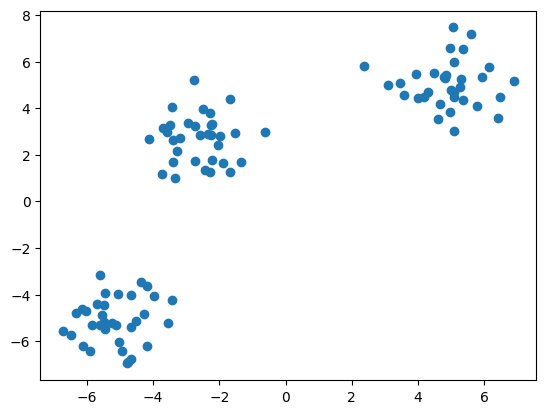

In [58]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [59]:
class KMeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters=n_clusters
        self.max_iter=max_iter
        self.centroids=None
    
    def assign_clusters(self,X):
        cluster_group=[]
        for row in X:
            distances=[]
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distances=min(distances)
            index_pos=distances.index(min_distances)
            cluster_group.append(index_pos)
        return np.array(cluster_group)
    
    def move_centroids(self,X,cluster_group):
        new_centroids=[]
        cluster_type=np.unique(cluster_group)
        for type in cluster_type:
            new_centroids.append(X[cluster_group==type].mean(axis=0))
        return np.array(new_centroids)
    
    def fit_predict(self,X):
        random_index=random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids=X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group=self.assign_clusters(X)
            old_centroids=self.centroids
            # move Centroids
            self.centroids=self.move_centroids(X,cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break
        
        return cluster_group

[0 2 1 2 0 2 1 0 2 2 2 0 1 0 0 0 2 0 0 1 1 0 0 1 0 2 1 2 0 2 1 2 2 0 2 1 0
 2 0 0 0 1 1 2 0 0 1 2 0 2 1 1 0 0 1 0 1 0 2 0 1 1 0 0 0 2 1 0 1 0 1 1 2 1
 2 0 2 2 2 1 2 1 1 1 2 1 2 2 2 1 2 1 1 1 1 2 2 2 0 2]


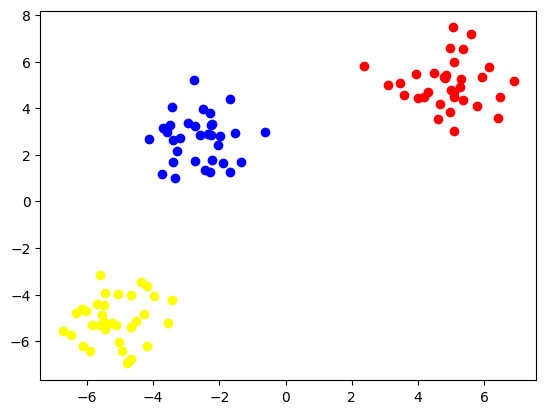

In [60]:
km=KMeans(n_clusters=3,max_iter=400)
y_means=km.fit_predict(X)
print(y_means)
plt.scatter(X[y_means==0,0],X[y_means==0,1],color='blue')
plt.scatter(X[y_means==1,0],X[y_means==1,1],color='red')
plt.scatter(X[y_means==2,0],X[y_means==2,1],color='yellow')
plt.show()